In [1]:
# ==============================================
# QUESTION 3: IRIS DATASET - ANN with TensorFlow
# ==============================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Sequential
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
# ==============================================
# 3a. Import the dataset (4 Marks)
# ==============================================
iris = load_iris()
X = iris.data           # (150, 4)
y = iris.target         # (150,)

# One-hot encode the labels for categorical crossentropy
encoder = OneHotEncoder(sparse_output=False)
y_encoded = encoder.fit_transform(y.reshape(-1, 1))

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train_scaled.shape[0]} samples")
print(f"Test set: {X_test_scaled.shape[0]} samples")

Training set: 120 samples
Test set: 30 samples


In [3]:
# ==============================================
# 3b. Sequentially Build the network (4 Marks)
# ==============================================
model = Sequential([
    # Input layer (4 features) + Hidden layer (6 neurons, ReLU)
    layers.Dense(6, activation='relu', input_shape=(4,), name='hidden_layer'),
    
    # Output layer (3 neurons, Softmax)
    layers.Dense(3, activation='softmax', name='output_layer')
])


c:\Users\xinod\Documents\Projects\CEC616\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:
# ==============================================
# 3c. Compile it with optimizer, Loss, and Metrics (4 Marks)
# ==============================================
model.compile(
    optimizer='adam',                      # Adaptive Moment Estimation
    loss='categorical_crossentropy',       # For multi-class classification
    metrics=['accuracy']
)


In [5]:
# ==============================================
# 3d. Check the summary of the model (4 Marks)
# ==============================================
print("\n" + "="*50)
print("MODEL SUMMARY")
print("="*50)
model.summary()

# ==============================================
# 3e. Train it (4 Marks)
# ==============================================
history = model.fit(
    X_train_scaled, 
    y_train,
    epochs=100,                    # Number of passes over data
    batch_size=16,                 # Samples per gradient update
    validation_split=0.2,          # 20% of training data for validation
    verbose=1
)

# ==============================================
# 3f. Check the score on the testing Set (4 Marks)
# ==============================================
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


MODEL SUMMARY


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer (Dense)            │ (None, 6)              │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51 (204.00 B)

 Trainable params: 51 (204.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - accuracy: 0.6875 - loss: 0.8373 - val_accuracy: 0.8333 - val_loss: 0.8364
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7396 - loss: 0.8241 - val_accuracy: 0.8333 - val_loss: 0.8243
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.7604 - loss: 0.8118 - val_accuracy: 0.8333 - val_loss: 0.8126
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7917 - loss: 0.7998 - val_accuracy: 0.8333 - val_loss: 0.8011
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7917 - loss: 0.7877 - val_accuracy: 0.8333 - val_loss: 0.7905
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7917 - loss: 0.7759 - val_accuracy: 0.8333 - val_loss: 0.7801
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7812 - loss: 0.7644 - val_accuracy: 0.8333 - val_loss: 0.7702
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7812 - loss: 0.7527 - val_accuracy: 0.8333 - val_loss:

In [6]:
# Predict on test set
y_pred_probs = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

print(f"\nPredictions: {y_pred}")
print(f"True labels: {y_true}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step

Predictions: [0 2 1 1 0 2 0 0 2 1 2 2 2 2 0 0 0 1 1 2 0 2 2 1 2 2 2 0 2 0]
True labels: [0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]


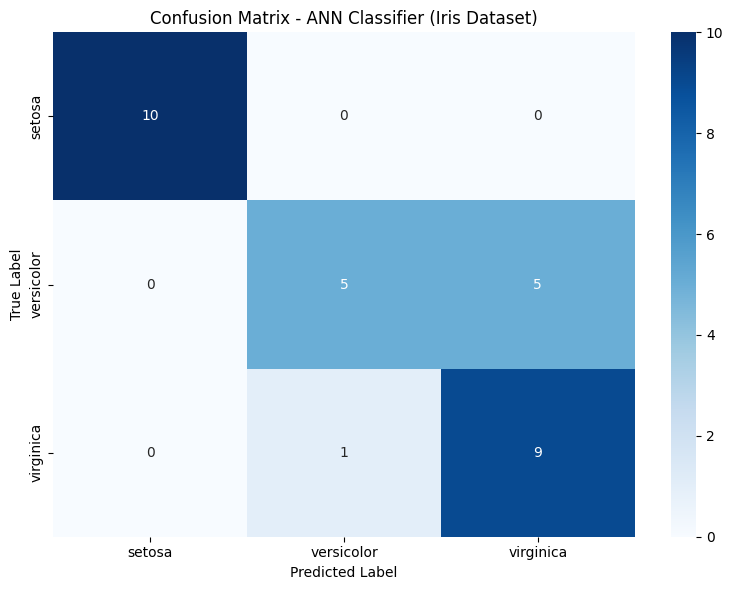

In [7]:
# ==============================================
# 3g. Plot the confusion Matrix (4 Marks)
# ==============================================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)
plt.title('Confusion Matrix - ANN Classifier (Iris Dataset)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

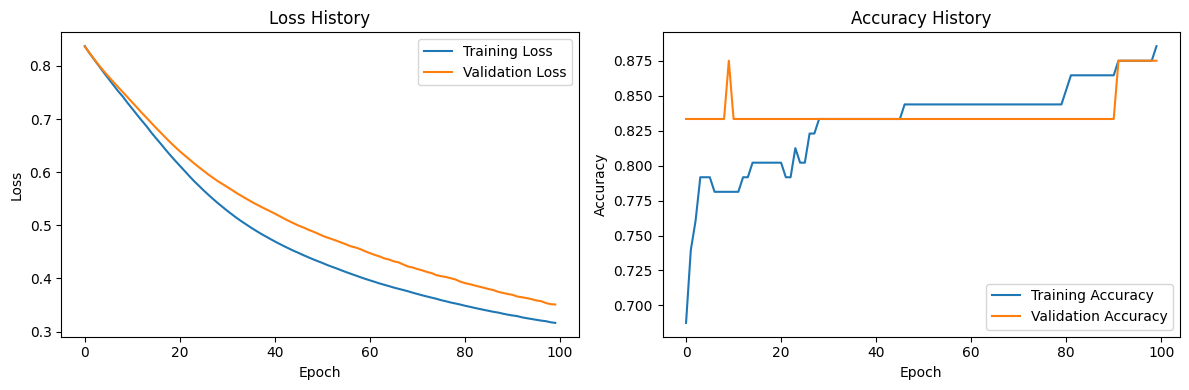

In [8]:
# ==============================================
# Optional: Plot training history
# ==============================================
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss History')

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy History')

plt.tight_layout()
plt.show()